In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Sphere, Cylinder, SandiB, SandiW, BallStickSharedDiffusivity, Ball3StickSharedDiffusivity, MultiCompartment,AllGaussianAndConvolvedModels
from dmri.simulators.acquisition_scheme import acquisition_scheme
from dmri.simulators import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


# Diffusion MRI Simulators

Based on bvals and bvecs, we can create an acquisition scheme.

In [4]:
bvals =  jnp.linspace(0, 3000, 100)
bvecs = jax.random.normal(jax.random.key(0), (100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

acq = acquisition_scheme(bvals, bvecs)

In [5]:
simulator = AllGaussianAndConvolvedModels.from_theta(np.random.randn(AllGaussianAndConvolvedModels.theta_dim))

In [8]:
from dmri.simulators.mask_prior import TotalParamPenalizedPrior
model_comp = len(simulator.model_types)
noise_comp = len(simulator.noise_types)
param_cout = [m.theta_dim for m in simulator.model_types]
prior = TotalParamPenalizedPrior(num_model_components=model_comp, num_noise_components=noise_comp, num_model_parameters=param_cout)

jax.vmap(prior.sample_model_components)(jax.random.split(jax.random.key(0), 10000),jnp.ones((10000))*0.5).mean(0)

Array([0.4319    , 0.3229    , 0.3205    , 0.3241    , 0.2715    ,
       0.2716    , 0.2674    , 0.1837    , 0.1893    , 0.1841    ,
       0.49719998, 0.2705    , 0.2289    , 0.182     , 0.1454    ,
       0.1209    , 0.18679999, 0.0766    , 0.1213    ], dtype=float32)

In [26]:
@jax.jit
@jax.vmap
def simulate(theta):
    model = AllGaussianAndConvolvedModels.from_theta(theta)
    signals = model.signal(acq)
    return signals
theta = jax.random.normal(jax.random.key(0), (4096,AllGaussianAndConvolvedModels.theta_dim,))


In [ ]:
%%timeit
signals = simulate(theta)

2.52 s ± 4.98 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


: 

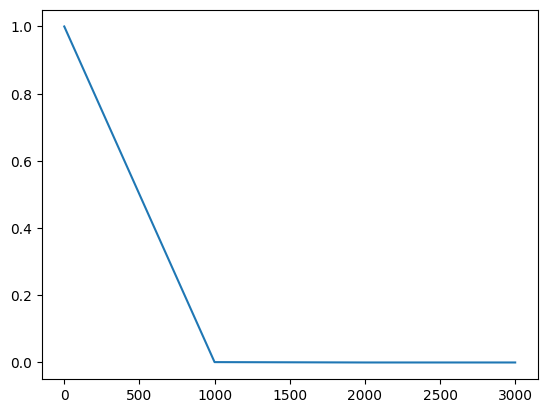

In [4]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

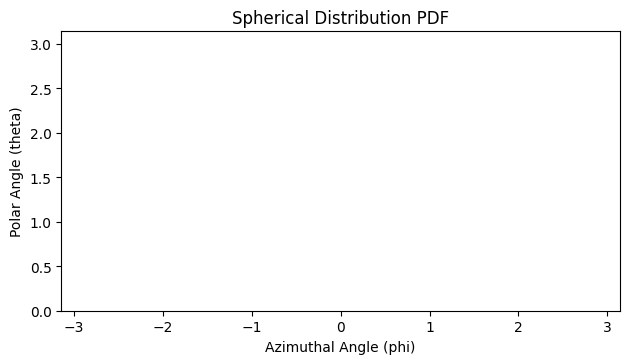

In [5]:
# Uniformly distributed signal
%matplotlib inline
ball.to_fod().viz()

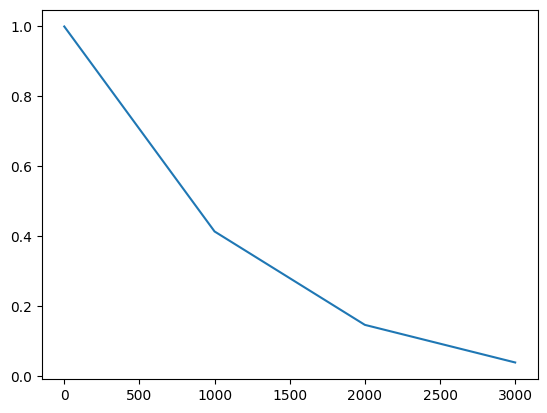

In [6]:
theta = np.random.randn(Sphere.theta_dim)
ball = Sphere.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

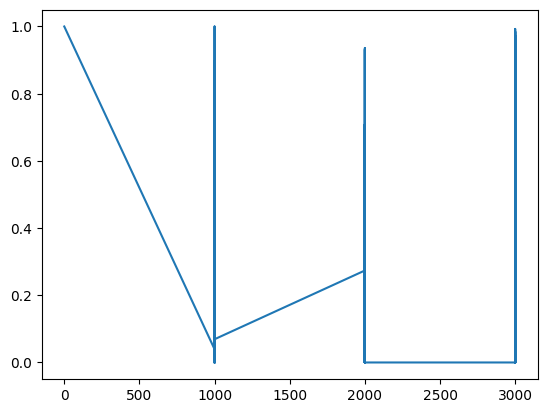

In [6]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

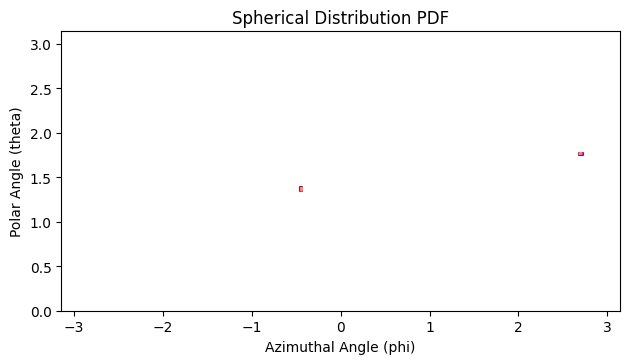

In [7]:
%matplotlib inline
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)
stick.to_fod().viz(plot_type='polar', color='plasma')

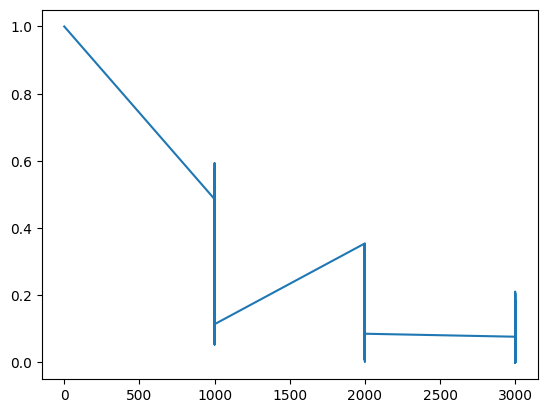

In [8]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(acq)

plt.plot(bvals, signal)

In [9]:
def stick_mu_samples(thetas):
    stick = Zeppelin.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

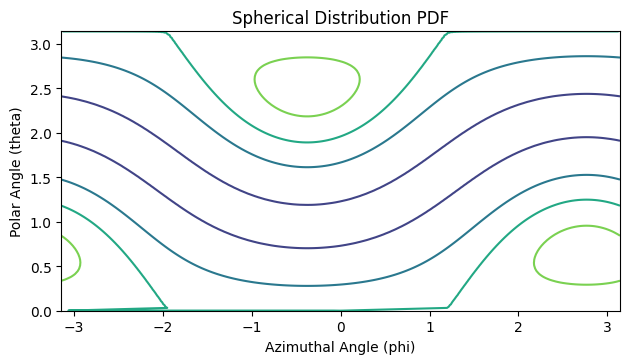

In [10]:
%matplotlib inline
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)
zep.to_fod().viz()

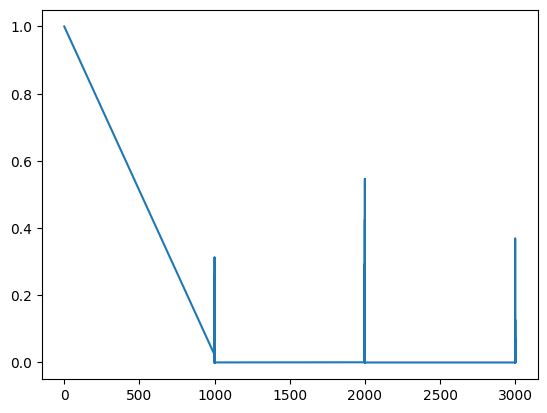

In [11]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(acq)

plt.plot(bvals, signal)

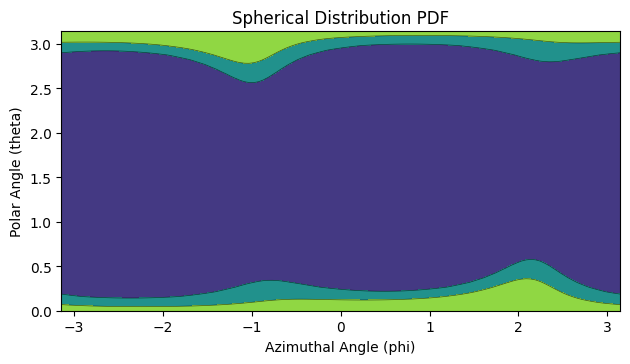

In [28]:
%matplotlib inline
dti.to_fod().viz()

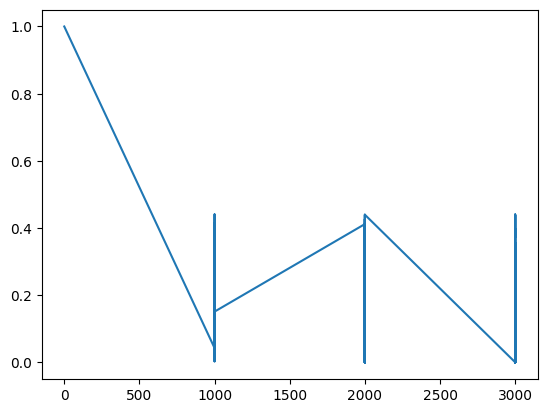

In [29]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

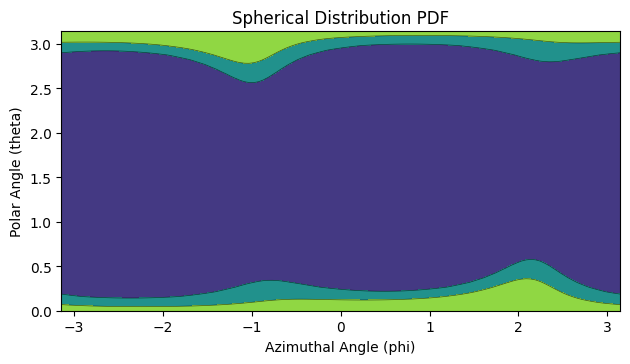

In [30]:
%matplotlib inline
dti.to_fod().viz()

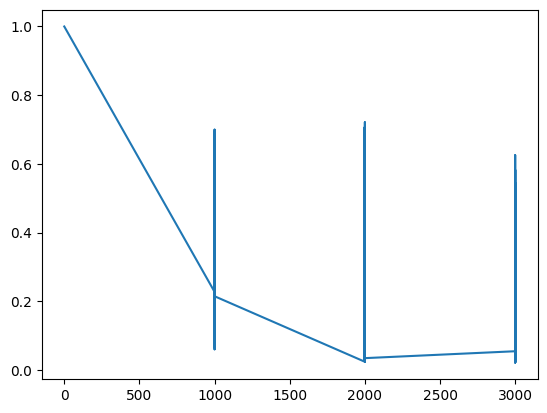

In [32]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

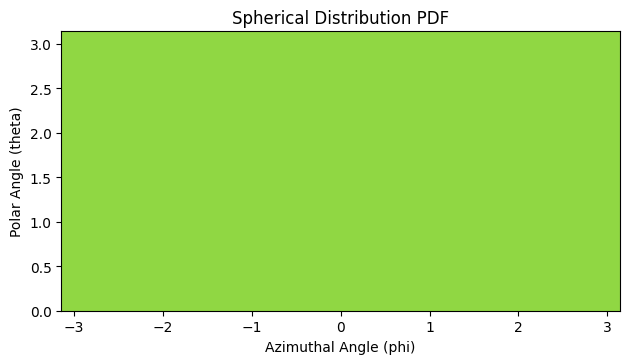

In [33]:
%matplotlib inline
ball_stick.to_fod().viz()

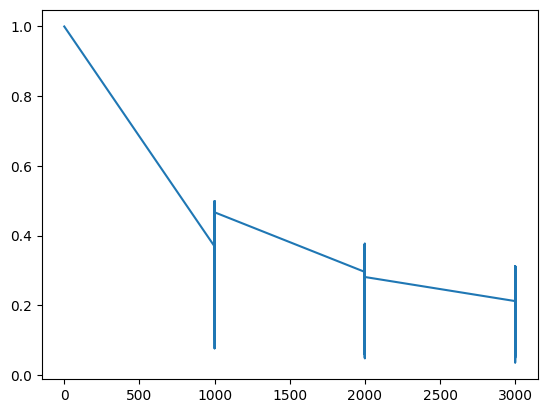

In [34]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

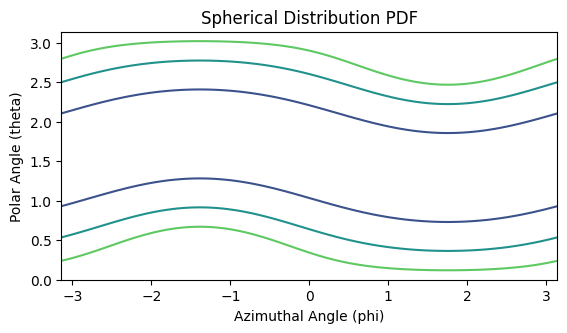

In [29]:
%matplotlib inline
racket.to_fod().viz()

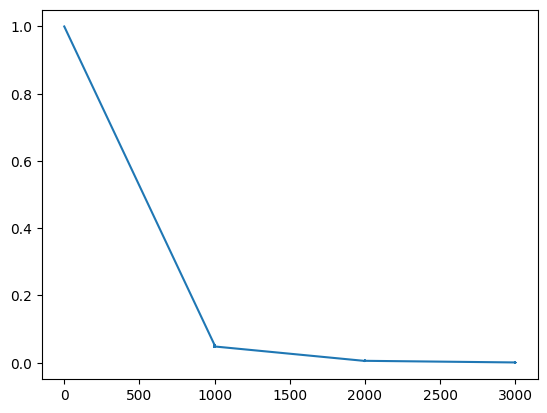

In [35]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(acq)
plt.plot(bvals, signal)

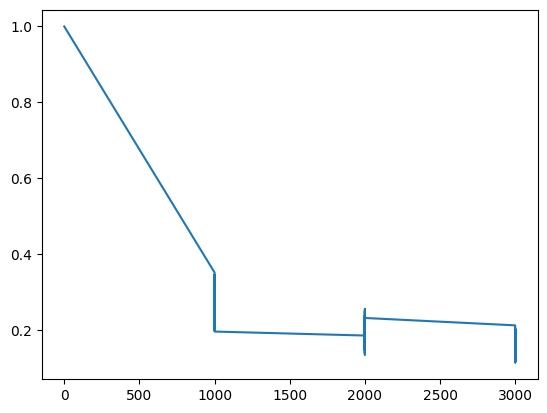

In [36]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(acq)
plt.plot(bvals, signal)

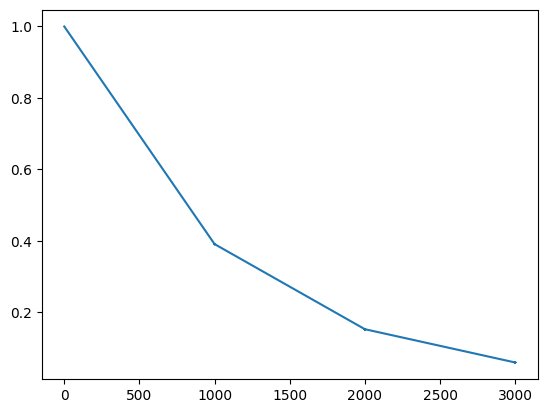

In [37]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

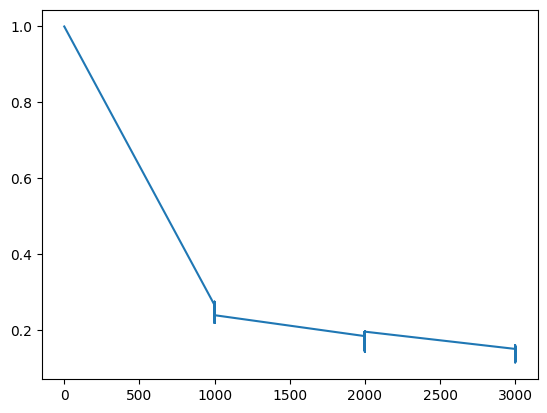

In [38]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

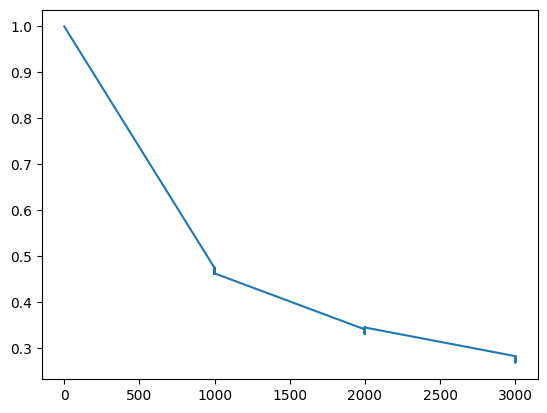

In [39]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

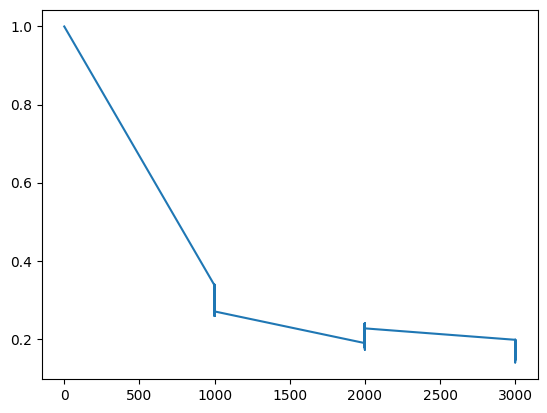

In [40]:
racket = SandiW.from_theta(np.random.randn(SandiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

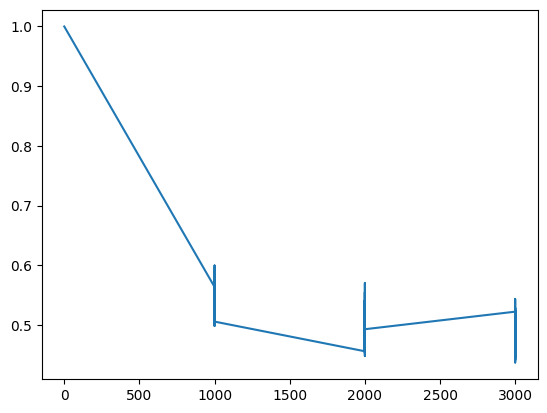

In [41]:
racket = SandiB.from_theta(np.random.randn(SandiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

# SSFP models

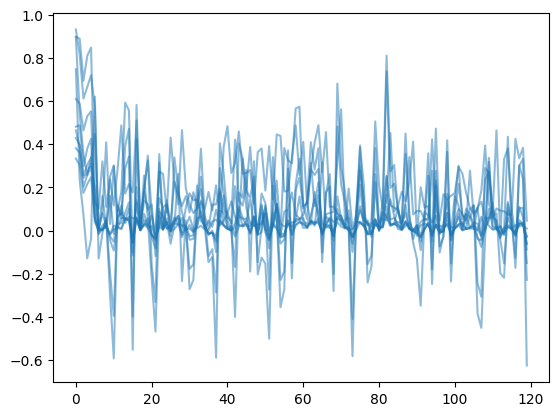

In [4]:
from dmri.simulators.local_signal_models.ball import SSFPBall
from dmri.simulators.acquisition_scheme import ssfp_acquisition_scheme, random_ssfp_acquisition
from dmri.simulators.multi_compartment import SSFPBall3StickSharedDiffusivity, Ball3StickSharedDiffusivity, SSFPBall3StickSharedDiffusivityBetterNorm


acq  = jax.jit(random_ssfp_acquisition)(jax.random.key(8))


def sim(theta):
    return SSFPBall3StickSharedDiffusivityBetterNorm.from_theta(theta).signal(acq, rng=jax.random.PRNGKey(0))

signals = jax.vmap(sim)(np.random.randn(10, SSFPBall3StickSharedDiffusivity.theta_dim))

idx = jnp.argsort(acq.qvals)
_ = plt.plot(signals[...,idx].T, color="C0", alpha=0.5)
#plt.ylim(0, 1.1)
